# Does vertical shear produce rotation-dependent EAC eddy tilt?

This notebook tests the mechanism suggested by Chao and Shaw (1998): differential advection produces an along-flow displacement, while interaction between the ambient flow and eddy rotation produces a transverse response whose sign reverses with rotation. The Arctic result is a hypothesis to test, not a sign convention to impose on the Southern Hemisphere EAC.

The existing `TiltDir` and `TiltDis` are the authoritative coherent tilt measurements. They are **never recomputed from raw centre positions**. `TiltDir` points from the deep fitted centre toward the shallow fitted centre, so all shear vectors use the matching **upper minus deep** convention. Positive cross-shear displacement is left of that vector.

Primary prediction: AE and CE should share an along-shear response but have opposite cross-shear responses. The most specific test is the `shear magnitude × Cyc` interaction, followed by a lagged test asking whether current shear predicts subsequent change in the measured tilt vector.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Launch from seacofs_eddy_tilt_analysis or one of its subfolders.')
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
MECHANISM_ROOT = ANALYSIS_ROOT / 'tilt_mechanisms'
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
THIS_ROOT = ANALYSIS_ROOT / 'shear_lift_tilt'
for folder in (ANALYSIS_ROOT, FLOW_ROOT, MECHANISM_ROOT, CASE_ROOT, THIS_ROOT):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics
import mechanism_tools as mech
from shear_lift_tools import (add_lagged_tilt_change, add_shear_relative_tilt,
                              add_shear_vectors, eddy_equal_binned_summary)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
# Predefined analysis choices. Change here, not after inspecting significance.
MIN_TILT_KM = 5.0
MIN_SHEAR_MS = 0.005
DOMINANCE_FACTOR = 2.0
PLANETARY_MIN_DEPTH_M = 3000.0
PRIMARY_FAMILY = 'clim'
PRIMARY_DEFINITION = 'upper_deep'  # 0-200 m minus 200-500 m
FAMILIES = ('clim', 'full')
DEFINITIONS = {
    'upper_deep': '0-200 m minus 200-500 m',
    'surface_deep': 'surface minus 200-500 m',
}
LAGS_DAYS = (1, 3, 5, 10)
COLORS = {'AE': 'firebrick', 'CE': 'royalblue'}

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
eddies, _ = tilt.load_tilt_tables(paths)
eddies = tilt.add_region_labels(eddies, grid)
eddies = tilt.add_pv_gradient_terms(eddies, grid, core_mean=True)
background = load_background_cache(BackgroundConfig()).drop(columns=['ic', 'jc'], errors='ignore')
required = {f'{family}_{depth}_{component}_ms' for family in FAMILIES
            for depth in ('surface', '200', '500') for component in ('east', 'north')}
if missing := required - set(background.columns):
    raise RuntimeError(f'Background cache missing {sorted(missing)}; run 01_build_background_cache.ipynb.')
if background.duplicated(['Eddy', 'Day']).any():
    raise ValueError('Background cache has duplicate Eddy-Day rows.')
data = eddies.merge(background, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
pv_config = PVAlignmentConfig(dominance_factor=DOMINANCE_FACTOR,
                              min_open_ocean_depth_m=PLANETARY_MIN_DEPTH_M,
                              min_tilt_distance_km=MIN_TILT_KM)
data = add_pv_alignment_diagnostics(data, pv_config)
data['PVShearRegime'] = np.select(
    [data.open_ocean_planetary, data.topographic_strong],
    ['planetary', 'topographic'], default='mixed')
data = add_shear_vectors(data, families=FAMILIES)
data = data.loc[data.TiltDis.ge(MIN_TILT_KM)].sort_values(['Eddy', 'Day']).copy()
if 'lat' not in data:
    ii = data.ic.astype(int).clip(0, grid.lat_rho.shape[0] - 1)
    jj = data.jc.astype(int).clip(0, grid.lat_rho.shape[1] - 1)
    data['lat'] = grid.lat_rho[ii, jj]
display(data.groupby(['PVShearRegime', 'Cyc'], observed=True).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_tilt_km=('TiltDis', 'median'), median_lat=('lat', 'median'),
    median_depth_m=('h', 'median')).round(2))

observations  eddies  median_tilt_km  median_lat  \
PVShearRegime Cyc                                                     
mixed         AE          16497     845           18.61      -36.62   
              CE           9717     684           15.54      -36.03   
planetary     AE           5184     364           16.64      -35.37   
              CE           1069     146           15.36      -35.05   
topographic   AE          27587    1194           24.47      -32.89   
              CE          35611    1452           18.83      -31.86   

                   median_depth_m  
PVShearRegime Cyc                  
mixed         AE          4673.75  
              CE          4687.99  
planetary     AE          4837.76  
              CE          4853.47  
topographic   AE          4175.42  
              CE          4043.60

## 1. Express the measured tilt in local shear coordinates

For shear unit vector $\hat{s}$, the notebook calculates $T_{\parallel}=\mathbf{T}\cdot\hat{s}$ and $T_{\mathrm{left}}=\mathbf{T}\cdot(\hat{k}\times\hat{s})$. Fractions divide these projections by `TiltDis`, separating direction from tilt magnitude. No polarity multiplier is applied.

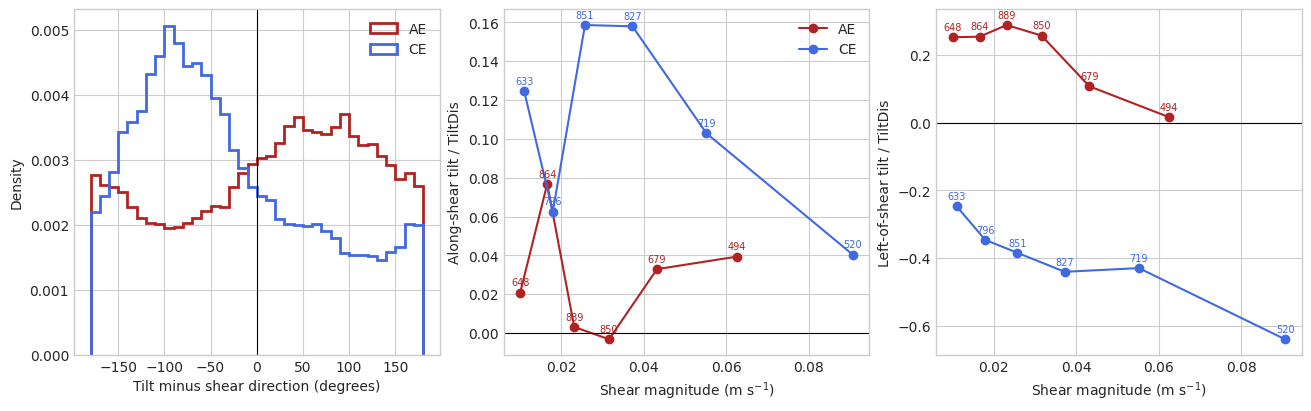

Numbers beside points are eddies, not observations.


In [3]:
relative_tables = {}
for family in FAMILIES:
    for definition in DEFINITIONS:
        prefix = f'{family}_{definition}'
        relative_tables[prefix] = add_shear_relative_tilt(
            data, f'{prefix}_east_ms', f'{prefix}_north_ms',
            prefix=prefix, minimum_shear_ms=MIN_SHEAR_MS,
        )
primary_prefix = f'{PRIMARY_FAMILY}_{PRIMARY_DEFINITION}'
primary = relative_tables[primary_prefix]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for cyc in ('AE', 'CE'):
    q = primary.loc[primary.Cyc.eq(cyc)]
    axes[0].hist(q[f'{primary_prefix}_offset_deg'].dropna(), bins=np.arange(-180, 181, 10),
                 density=True, histtype='step', lw=2, color=COLORS[cyc], label=cyc)
    for ax, response, ylabel in (
        (axes[1], f'{primary_prefix}_tilt_parallel_fraction', 'Along-shear tilt / TiltDis'),
        (axes[2], f'{primary_prefix}_tilt_left_fraction', 'Left-of-shear tilt / TiltDis')):
        summary = eddy_equal_binned_summary(q, f'{primary_prefix}_shear_mag_ms', response)
        ax.plot(summary.x, summary.y, 'o-', color=COLORS[cyc], label=cyc)
        for row in summary.itertuples():
            ax.annotate(str(row.eddies), (row.x, row.y), xytext=(0, 5),
                        textcoords='offset points', ha='center', fontsize=7, color=COLORS[cyc])
axes[0].axvline(0, color='k', lw=.8); axes[0].set(xlabel='Tilt minus shear direction (degrees)', ylabel='Density')
for ax in axes[1:]:
    ax.axhline(0, color='k', lw=.8); ax.set_xlabel('Shear magnitude (m s$^{-1}$)')
axes[1].set_ylabel('Along-shear tilt / TiltDis'); axes[2].set_ylabel('Left-of-shear tilt / TiltDis')
axes[0].legend(); axes[1].legend(); plt.show()
print('Numbers beside points are eddies, not observations.')

## 2. Clustered same-day mechanism models

The directional models use normalized projections, while the kilometre models retain amplitude. GEE clusters repeated days by eddy and adjusts flexibly for latitude. The mechanism-specific coefficient is the difference between the CE and AE shear-magnitude slopes. A significant interaction alone is not sufficient: the fitted polarity-specific slopes should also have opposing signs for the cross-shear response.

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p
0,same_day,clim_upper_deep,tilt_parallel_fraction,AE,48153,1420,-0.8645,-1.7501,0.0210,0.0557,0.4684
1,same_day,clim_upper_deep,tilt_parallel_fraction,CE,45269,1529,-0.5024,-0.9461,-0.0586,0.0265,0.4684
2,same_day,clim_upper_deep,tilt_left_fraction,AE,48153,1420,-2.0496,-2.9357,-1.1634,0.0000,0.8546
3,same_day,clim_upper_deep,tilt_left_fraction,CE,45269,1529,-2.1415,-2.5890,-1.6940,0.0000,0.8546
4,same_day,clim_upper_deep,tilt_parallel_km,AE,48153,1420,-22.5930,-51.7802,6.5942,0.1292,0.9518
5,same_day,clim_upper_deep,tilt_parallel_km,CE,45269,1529,-23.5808,-37.0635,-10.0982,0.0006,0.9518
6,same_day,clim_upper_deep,tilt_left_km,AE,48153,1420,-72.9894,-100.8685,-45.1104,0.0000,0.0938
7,same_day,clim_upper_deep,tilt_left_km,CE,45269,1529,-46.3854,-60.4253,-32.3454,0.0000,0.0938
8,same_day,clim_surface_deep,tilt_parallel_fraction,AE,49111,1421,-0.4359,-1.1305,0.2586,0.2186,0.5411
9,same_day,clim_surface_deep,tilt_parallel_fraction,CE,46247,1530,-0.1950,-0.5473,0.1572,0.2779,0.5411


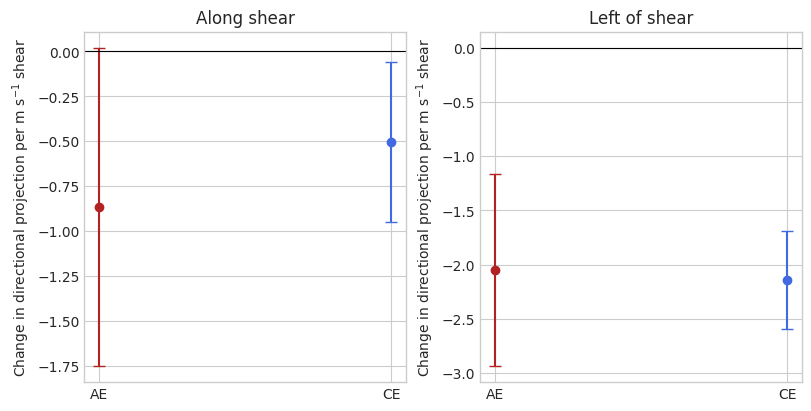

In [4]:
def fit_shear_gee(frame, prefix, response_suffix, analysis):
    mag = f'{prefix}_shear_mag_ms'; response = f'{prefix}_{response_suffix}'
    columns = ['Eddy', 'Cyc', 'lat', 'Region', mag, response]
    use = frame[columns].replace([np.inf, -np.inf], np.nan).dropna().rename(
        columns={mag: 'shear_mag_ms', response: 'response'})
    if use.Cyc.nunique() < 2 or use.Eddy.nunique() < 10:
        return None, []
    fit = smf.gee('response ~ shear_mag_ms * C(Cyc) + bs(lat, df=4)',
                  groups='Eddy', data=use).fit()
    names = list(fit.params.index); rows = []
    for cyc in ('AE', 'CE'):
        contrast = np.zeros(len(names)); contrast[names.index('shear_mag_ms')] = 1
        interaction = 'shear_mag_ms:C(Cyc)[T.CE]'
        if cyc == 'CE' and interaction in names:
            contrast[names.index(interaction)] = 1
        test = fit.t_test(contrast); ci = np.asarray(test.conf_int()).ravel()
        part = use.loc[use.Cyc.eq(cyc)]
        rows.append(dict(analysis=analysis, prefix=prefix, response=response_suffix, Cyc=cyc,
                         observations=len(part), eddies=part.Eddy.nunique(),
                         slope=float(np.asarray(test.effect).item()), ci_low=float(ci[0]),
                         ci_high=float(ci[1]), p_value=float(np.asarray(test.pvalue).item()),
                         interaction_p=float(fit.pvalues.get(interaction, np.nan))))
    return fit, rows

same_day_rows = []
for prefix, frame in relative_tables.items():
    for suffix in ('tilt_parallel_fraction', 'tilt_left_fraction',
                   'tilt_parallel_km', 'tilt_left_km'):
        _, rows = fit_shear_gee(frame, prefix, suffix, 'same_day')
        same_day_rows.extend(rows)
same_day_models = pd.DataFrame(same_day_rows)
display(same_day_models.round(4))

shown = same_day_models.query("prefix == @primary_prefix and response in ['tilt_parallel_fraction','tilt_left_fraction']")
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
for ax, suffix, title in zip(axes, ('tilt_parallel_fraction', 'tilt_left_fraction'),
                             ('Along shear', 'Left of shear')):
    q = shown.loc[shown.response.eq(suffix)]
    for x, cyc in enumerate(('AE', 'CE')):
        row = q.loc[q.Cyc.eq(cyc)].iloc[0]
        ax.errorbar(x, row.slope, [[row.slope-row.ci_low], [row.ci_high-row.slope]],
                    fmt='o', capsize=4, color=COLORS[cyc])
    ax.axhline(0, color='k', lw=.8); ax.set_xticks((0, 1), ('AE', 'CE'))
    ax.set(title=title, ylabel='Change in directional projection per m s$^{-1}$ shear')
plt.show()

## 3. Does shear precede a change in coherent tilt?

These are exact 1, 3, 5 and 10-day matches within the same eddy. Each response is the future `TiltDir`/`TiltDis` vector minus the current `TiltDir`/`TiltDis` vector, projected onto the **current** shear basis. This retains the coherent tilt estimates at both endpoints and avoids differencing raw fitted centres.

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p
0,lag_1d_parallel,clim_upper_deep,lag_response,AE,45644,1417,5.6727,2.6954,8.6500,0.0002,0.0000
1,lag_1d_parallel,clim_upper_deep,lag_response,CE,42814,1527,-4.2830,-5.7716,-2.7944,0.0000,0.0000
2,lag_1d_left,clim_upper_deep,lag_response,AE,45644,1417,-1.6000,-4.2598,1.0598,0.2384,0.0047
3,lag_1d_left,clim_upper_deep,lag_response,CE,42814,1527,2.5906,1.3134,3.8679,0.0001,0.0047
4,lag_3d_parallel,clim_upper_deep,lag_response,AE,41834,1408,6.0124,3.1695,8.8553,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
59,lag_5d_left,full_surface_deep,lag_response,CE,35672,1505,3.1452,2.0148,4.2756,0.0000,0.0049
60,lag_10d_parallel,full_surface_deep,lag_response,AE,32846,1358,3.6763,1.5000,5.8526,0.0009,0.0004
61,lag_10d_parallel,full_surface_deep,lag_response,CE,28880,1467,-0.6181,-1.6885,0.4523,0.2577,0.0004
62,lag_10d_left,full_surface_deep,lag_response,AE,32846,1358,-1.0692,-3.0634,0.9249,0.2933,0.0001


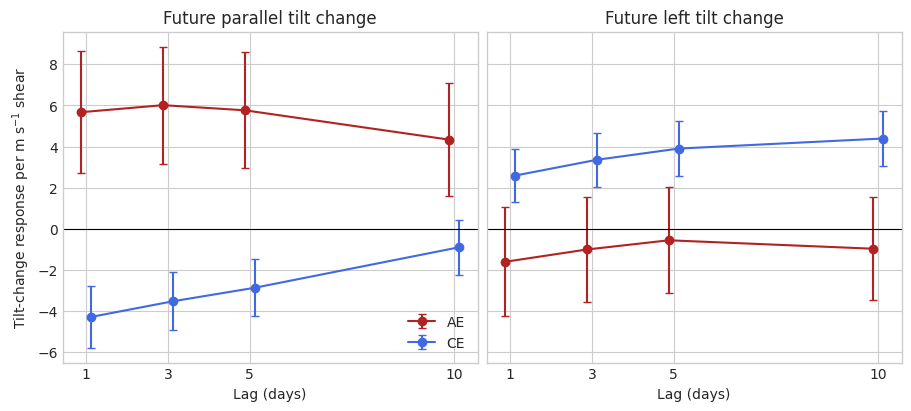

In [5]:
lag_rows = []
for prefix, frame in relative_tables.items():
    for lag in LAGS_DAYS:
        lagged = add_lagged_tilt_change(frame, lag_days=lag, prefix=prefix)
        for direction in ('parallel', 'left'):
            response = f'{prefix}_{lag}d_dtilt_{direction}_km_day'
            model_frame = lagged.rename(columns={response: f'{prefix}_lag_response'})
            _, rows = fit_shear_gee(model_frame, prefix, 'lag_response', f'lag_{lag}d_{direction}')
            lag_rows.extend(rows)
lag_models = pd.DataFrame(lag_rows)
display(lag_models.round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True, constrained_layout=True)
for ax, direction in zip(axes, ('parallel', 'left')):
    q = lag_models.loc[(lag_models.prefix == primary_prefix) &
                       lag_models.analysis.str.endswith(direction)]
    for offset, cyc in zip((-.12, .12), ('AE', 'CE')):
        part = q.loc[q.Cyc.eq(cyc)].copy()
        part['lag'] = part.analysis.str.extract(r'lag_(\d+)d')[0].astype(int)
        part = part.sort_values('lag')
        axes_x = part.lag + offset
        ax.errorbar(axes_x, part.slope, [part.slope-part.ci_low, part.ci_high-part.slope],
                    fmt='o-', capsize=3, color=COLORS[cyc], label=cyc)
    ax.axhline(0, color='k', lw=.8); ax.set_xticks(LAGS_DAYS)
    ax.set(xlabel='Lag (days)', title=f'Future {direction} tilt change')
axes[0].set_ylabel('Tilt-change response per m s$^{-1}$ shear')
axes[0].legend(); plt.show()

## 4. Does the shear-relative response explain poleward/equatorward tilt?

A rotation-dependent transverse mechanism explains the geographic AE-equatorward/CE-poleward result only if the local left/right shear normals project consistently onto north/south. This section compares those projections by latitude and region, then audits whether the conclusions survive all four predefined shear estimates.

observations  eddies  median_left_normal_poleward  \
Region Cyc                                                      
D1     AE          20873     686                       -0.864   
       CE          13996     612                       -0.839   
D2     AE           6751     281                       -0.975   
       CE           4987     213                       -0.978   
S1     AE           2118     164                       -0.090   
       CE           3641     215                        0.063   
S2     AE           4188     227                        0.024   
       CE           5798     357                        0.229   
U1     AE           6869     300                       -0.449   
       CE           7067     301                       -0.448   
U2     AE           8469     339                       -0.876   
       CE          10908     408                       -0.855   

            median_tilt_poleward_km  
Region Cyc                           
D1     AE                    -5.991  
       CE                     5.492  
D2     AE                    -8.816  
       CE                     5.244  
S1     AE                    -7.045  
       CE                    -1.345  
S2     AE                    -7.590  
       CE                     1.145  
U1     AE                   -10.302  
       CE                    11.130  
U2     AE                   -11.547  
       CE                     6.784

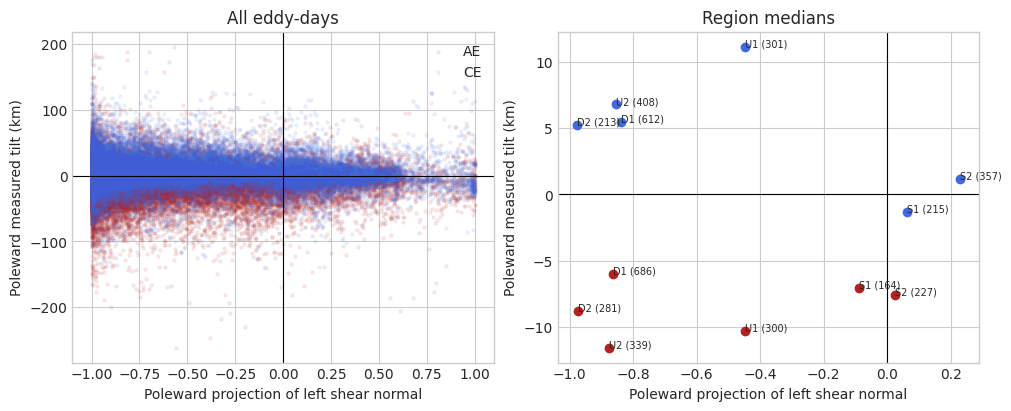

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p,opposite_cross_slopes
10,same_day,clim_surface_deep,tilt_left_fraction,AE,49111,1421,-1.1089,-1.7559,-0.4619,0.0008,0.0156,False
11,same_day,clim_surface_deep,tilt_left_fraction,CE,46247,1530,-2.0039,-2.3368,-1.6710,0.0000,0.0156,False
2,same_day,clim_upper_deep,tilt_left_fraction,AE,48153,1420,-2.0496,-2.9357,-1.1634,0.0000,0.8546,False
3,same_day,clim_upper_deep,tilt_left_fraction,CE,45269,1529,-2.1415,-2.5890,-1.6940,0.0000,0.8546,False
26,same_day,full_surface_deep,tilt_left_fraction,AE,48777,1420,-1.7865,-2.4865,-1.0865,0.0000,0.6578,False
27,same_day,full_surface_deep,tilt_left_fraction,CE,45521,1530,-1.6119,-1.9465,-1.2773,0.0000,0.6578,False
18,same_day,full_upper_deep,tilt_left_fraction,AE,48431,1418,-2.8324,-3.7802,-1.8846,0.0000,0.0409,False
19,same_day,full_upper_deep,tilt_left_fraction,CE,45255,1527,-1.7446,-2.1951,-1.2941,0.0000,0.0409,False
8,same_day,clim_surface_deep,tilt_parallel_fraction,AE,49111,1421,-0.4359,-1.1305,0.2586,0.2186,0.5411,False
9,same_day,clim_surface_deep,tilt_parallel_fraction,CE,46247,1530,-0.1950,-0.5473,0.1572,0.2779,0.5411,False


In [6]:
projection = primary.copy()
projection[f'{primary_prefix}_left_normal_north'] = projection[f'{primary_prefix}_unit_east']
projection['poleward_sign'] = np.sign(projection.lat)
projection[f'{primary_prefix}_left_normal_poleward'] = (
    projection[f'{primary_prefix}_left_normal_north'] * projection.poleward_sign)
projection['tilt_poleward_km'] = projection.tilt_north_km * projection.poleward_sign
display(projection.groupby(['Region', 'Cyc'], observed=True).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_left_normal_poleward=(f'{primary_prefix}_left_normal_poleward', 'median'),
    median_tilt_poleward_km=('tilt_poleward_km', 'median')).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for cyc in ('AE', 'CE'):
    q = projection.loc[projection.Cyc.eq(cyc)]
    axes[0].scatter(q[f'{primary_prefix}_left_normal_poleward'], q['tilt_poleward_km'],
                    s=5, alpha=.08, color=COLORS[cyc], label=cyc)
    region = q.groupby('Region', observed=True).agg(
        normal=(f'{primary_prefix}_left_normal_poleward', 'median'),
        tilt=('tilt_poleward_km', 'median'), eddies=('Eddy', 'nunique')).reset_index()
    axes[1].plot(region.normal, region.tilt, 'o', color=COLORS[cyc], label=cyc)
    for row in region.itertuples():
        axes[1].annotate(f'{row.Region} ({row.eddies})', (row.normal, row.tilt), fontsize=7)
for ax in axes:
    ax.axhline(0, color='k', lw=.8); ax.axvline(0, color='k', lw=.8)
    ax.set(xlabel='Poleward projection of left shear normal', ylabel='Poleward measured tilt (km)')
axes[0].set_title('All eddy-days'); axes[1].set_title('Region medians'); axes[0].legend(); plt.show()

audit = same_day_models.loc[same_day_models.response.isin(
    ['tilt_parallel_fraction', 'tilt_left_fraction'])].copy()
audit['opposite_cross_slopes'] = audit.groupby(['prefix', 'response']).slope.transform(
    lambda x: np.sign(x.iloc[0]) != np.sign(x.iloc[-1]) if len(x) == 2 else False)
display(audit.sort_values(['response', 'prefix', 'Cyc']).round(4))

## 5. Primary planetary-dominated test versus topographic complication

The central hypothesis is now tested explicitly: open-ocean planetary-dominated eddies should reveal the cleanest shear-relative polarity signal, whereas topographic-dominated eddies may have a weaker, rotated or nonlinear response. Regimes use the same centred 7-day PV-ratio smoothing and factor-of-two threshold as the existing case-study notebooks. Planetary days additionally require $h\geq3000$ m.

Mixed days are retained in the sample audit but excluded from the primary planetary-versus-topographic contrast. Because the planetary sample can be small, every table reports both eddy-days and unique eddies and models are skipped rather than trusted when fewer than ten eddies or only one polarity is available.

,PVShearRegime,Cyc,observations,eddies,shear_ms,parallel_fraction,left_fraction,tilt_km,depth_m
0,planetary,AE,5184,364,0.036,0.111,0.275,16.639,4837.759
1,planetary,CE,1069,146,0.038,0.309,-0.805,15.364,4853.465
2,topographic,AE,27587,1194,0.025,0.011,0.212,24.467,4175.421
3,topographic,CE,35611,1452,0.029,0.024,-0.470,18.827,4043.596


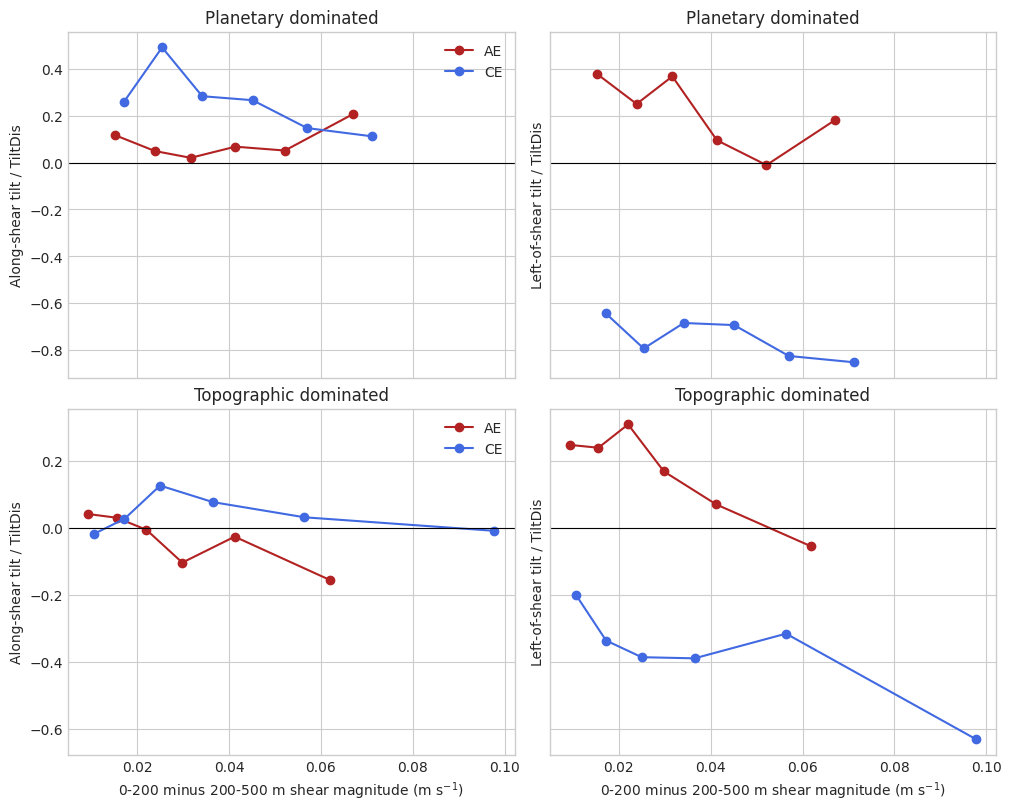

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p
0,planetary_same_day,clim_upper_deep,tilt_parallel_fraction,AE,5143,361,2.1127,-0.3967,4.6220,0.0989,0.0005
1,planetary_same_day,clim_upper_deep,tilt_parallel_fraction,CE,1061,142,-5.5782,-9.1094,-2.0470,0.0020,0.0005
2,planetary_same_day,clim_upper_deep,tilt_left_fraction,AE,5143,361,-0.9807,-3.3174,1.3559,0.4107,0.0666
3,planetary_same_day,clim_upper_deep,tilt_left_fraction,CE,1061,142,-5.0245,-8.7038,-1.3451,0.0074,0.0666
4,topographic_same_day,clim_upper_deep,tilt_parallel_fraction,AE,26843,1192,-1.8361,-2.9534,-0.7188,0.0013,0.0090
5,topographic_same_day,clim_upper_deep,tilt_parallel_fraction,CE,34608,1451,-0.2444,-0.7166,0.2278,0.3104,0.0090
6,topographic_same_day,clim_upper_deep,tilt_left_fraction,AE,26843,1192,-2.5105,-3.6476,-1.3734,0.0000,0.5591
7,topographic_same_day,clim_upper_deep,tilt_left_fraction,CE,34608,1451,-2.1493,-2.6126,-1.6860,0.0000,0.5591


In [7]:
regime_data = primary.loc[primary.PVShearRegime.isin(['planetary', 'topographic'])].copy()
regime_summary = regime_data.groupby(['PVShearRegime', 'Cyc'], observed=True).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    shear_ms=(f'{primary_prefix}_shear_mag_ms', 'median'),
    parallel_fraction=(f'{primary_prefix}_tilt_parallel_fraction', 'median'),
    left_fraction=(f'{primary_prefix}_tilt_left_fraction', 'median'),
    tilt_km=('TiltDis', 'median'), depth_m=('h', 'median')).reset_index()
display(regime_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex='col', sharey='row', constrained_layout=True)
for row, regime in enumerate(('planetary', 'topographic')):
    for col, (suffix, ylabel) in enumerate((('tilt_parallel_fraction', 'Along-shear tilt / TiltDis'),
                                             ('tilt_left_fraction', 'Left-of-shear tilt / TiltDis'))):
        ax = axes[row, col]
        for cyc in ('AE', 'CE'):
            q = regime_data.loc[(regime_data.PVShearRegime == regime) & regime_data.Cyc.eq(cyc)]
            summary = eddy_equal_binned_summary(
                q, f'{primary_prefix}_shear_mag_ms', f'{primary_prefix}_{suffix}')
            if not summary.empty:
                ax.plot(summary.x, summary.y, 'o-', color=COLORS[cyc], label=cyc)
        ax.axhline(0, color='k', lw=.8); ax.set(ylabel=ylabel, title=f'{regime.capitalize()} dominated')
        if row == 1:
            ax.set_xlabel('0-200 minus 200-500 m shear magnitude (m s$^{-1}$)')
        if col == 0:
            ax.legend()
plt.show()

regime_model_rows = []
for regime in ('planetary', 'topographic'):
    part = regime_data.loc[regime_data.PVShearRegime.eq(regime)]
    for suffix in ('tilt_parallel_fraction', 'tilt_left_fraction'):
        _, rows = fit_shear_gee(part, primary_prefix, suffix, f'{regime}_same_day')
        regime_model_rows.extend(rows)
regime_models = pd.DataFrame(regime_model_rows)
display(regime_models.round(4))

## 6. Within-eddy, nonlinear and rotation-strength checks

A spatial association can arise because eddies living in different environments experience different typical shear. The within/between model separates daily departures from each eddy's mean shear from differences among eddies. The spline model checks the visibly nonlinear same-day response. The final model asks whether the shear response changes with fitted rotation strength $|w|$; it does not use the sign of `w` to define the expected result.

In [8]:
mag = f'{primary_prefix}_shear_mag_ms'
model_diagnostics = []
for regime in ('planetary', 'topographic'):
    part = regime_data.loc[regime_data.PVShearRegime.eq(regime)].copy()
    part = mech.standardise_within_between(part, [mag])
    for direction in ('parallel', 'left'):
        response = f'{primary_prefix}_tilt_{direction}_fraction'
        columns = ['Eddy', 'Cyc', 'lat', 'Region', 'w', response, mag,
                   f'{mag}_within', f'{mag}_between']
        use = part[columns].replace([np.inf, -np.inf], np.nan).dropna(subset=[
            'Eddy', 'Cyc', 'lat', 'Region', response, mag, f'{mag}_within', f'{mag}_between'])
        if use.Cyc.nunique() < 2 or use.Eddy.nunique() < 10:
            continue
        fit_wb = smf.gee(
            f'{response} ~ {mag}_within * C(Cyc) + {mag}_between * C(Cyc) + '
            'bs(lat, df=4) + C(Region)', groups='Eddy', data=use).fit()
        fit_spline = smf.gee(
            f'{response} ~ bs({mag}, df=4) * C(Cyc) + bs(lat, df=4) + C(Region)',
            groups='Eddy', data=use).fit()
        model_diagnostics.append(dict(
            regime=regime, direction=direction, observations=len(use), eddies=use.Eddy.nunique(),
            qic_within_between=fit_wb.qic()[0], qic_spline=fit_spline.qic()[0],
            within_ae=fit_wb.params.get(f'{mag}_within', np.nan),
            within_interaction_p=fit_wb.pvalues.get(f'{mag}_within:C(Cyc)[T.CE]', np.nan),
            between_ae=fit_wb.params.get(f'{mag}_between', np.nan),
            between_interaction_p=fit_wb.pvalues.get(f'{mag}_between:C(Cyc)[T.CE]', np.nan)))
        if use.w.notna().sum() and use.w.abs().nunique() > 5:
            rot = use.dropna(subset=['w']).copy()
            rot['rotation_strength_z'] = rot.groupby('Cyc').w.transform(
                lambda x: (x.abs() - x.abs().mean()) / x.abs().std())
            fit_rot = smf.gee(
                f'{response} ~ {mag} * C(Cyc) * rotation_strength_z + '
                'bs(lat, df=4) + C(Region)', groups='Eddy', data=rot).fit()
            model_diagnostics[-1]['rotation_three_way_p'] = fit_rot.pvalues.get(
                f'{mag}:C(Cyc)[T.CE]:rotation_strength_z', np.nan)
display(pd.DataFrame(model_diagnostics).round(4))
print('Lower QIC is preferred. Interpret rotation strength only if |w| has adequate spread in both polarities.')

/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "
/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "
/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "
/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for compa

,regime,direction,observations,eddies,qic_within_between,qic_spline,within_ae,within_interaction_p,between_ae,between_interaction_p,rotation_three_way_p
0,planetary,parallel,6204,503,6342.6723,6355.1769,5.7330,0.0000,-0.4309,0.1573,0.6975
1,planetary,left,6204,503,6326.2676,6344.6183,-1.3246,0.1059,1.5127,0.1275,0.4025
2,topographic,parallel,61451,2643,61766.6892,61818.5613,1.0484,0.0104,-1.0203,0.0005,0.3807
3,topographic,left,61451,2643,61770.4391,61819.4073,-0.9996,0.0005,-1.7131,0.6340,0.0100


Lower QIC is preferred. Interpret rotation strength only if |w| has adequate spread in both polarities.


## 7. Controlled lagged planetary-versus-topographic comparison

These models add the current projection, current total tilt, region and latitude. Controlling the current state reduces the chance that apparent tilt change is merely regression toward zero. The interaction still asks whether shear predicts different subsequent changes for AE and CE within each PV regime.

,regime,lag_days,direction,observations,eddies,ae_shear_slope,ce_minus_ae_slope,interaction_p,current_state_p
0,planetary,1,parallel,5348,476,13.2475,-21.5511,0.0422,0.0
1,planetary,1,left,5348,476,-3.3184,-9.9808,0.4042,0.0
2,planetary,3,parallel,4055,406,15.1220,-30.3705,0.0059,0.0
3,planetary,3,left,4055,406,2.9712,-18.8038,0.1222,0.0
4,planetary,5,parallel,3108,325,14.1257,-40.0349,0.0015,0.0
5,planetary,5,left,3108,325,3.7463,-28.6020,0.0165,0.0
6,planetary,10,parallel,1905,203,8.8251,-53.8361,0.0012,0.0
7,planetary,10,left,1905,203,0.5066,-18.4546,0.1616,0.0
8,topographic,1,parallel,57027,2601,7.3434,-10.8122,0.0000,0.0
9,topographic,1,left,57027,2601,-3.9375,5.3616,0.0123,0.0


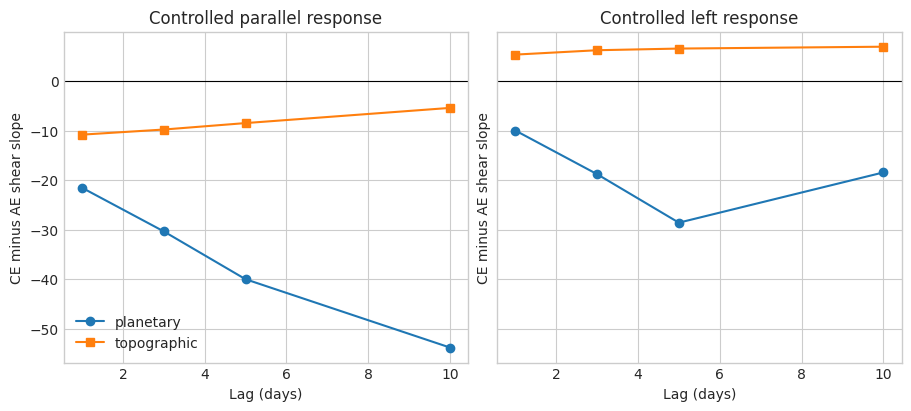

In [9]:
controlled_lag_rows = []
for regime in ('planetary', 'topographic'):
    base = primary.loc[primary.PVShearRegime.eq(regime)].copy()
    for lag in LAGS_DAYS:
        future = add_lagged_tilt_change(base, lag_days=lag, prefix=primary_prefix)
        for direction in ('parallel', 'left'):
            response = f'{primary_prefix}_{lag}d_dtilt_{direction}_km_day'
            current = f'{primary_prefix}_tilt_{direction}_km'
            columns = ['Eddy', 'Cyc', 'lat', 'Region', 'TiltDis', mag, current, response]
            use = future[columns].replace([np.inf, -np.inf], np.nan).dropna()
            if use.Cyc.nunique() < 2 or use.Eddy.nunique() < 10:
                continue
            fit = smf.gee(
                f'{response} ~ {mag} * C(Cyc) + {current} + TiltDis + '
                'bs(lat, df=4) + C(Region)', groups='Eddy', data=use).fit()
            interaction = f'{mag}:C(Cyc)[T.CE]'
            controlled_lag_rows.append(dict(
                regime=regime, lag_days=lag, direction=direction,
                observations=len(use), eddies=use.Eddy.nunique(),
                ae_shear_slope=fit.params.get(mag, np.nan),
                ce_minus_ae_slope=fit.params.get(interaction, np.nan),
                interaction_p=fit.pvalues.get(interaction, np.nan),
                current_state_p=fit.pvalues.get(current, np.nan)))
controlled_lag_models = pd.DataFrame(controlled_lag_rows)
display(controlled_lag_models.round(4))

if not controlled_lag_models.empty:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True, constrained_layout=True)
    for ax, direction in zip(axes, ('parallel', 'left')):
        for regime, marker in (('planetary', 'o'), ('topographic', 's')):
            q = controlled_lag_models.loc[(controlled_lag_models.direction == direction) &
                                            (controlled_lag_models.regime == regime)]
            ax.plot(q.lag_days, q.ce_minus_ae_slope, marker=marker, label=regime)
        ax.axhline(0, color='k', lw=.8); ax.set(xlabel='Lag (days)',
            ylabel='CE minus AE shear slope', title=f'Controlled {direction} response')
    axes[0].legend(); plt.show()

## Interpretation checklist

Support for a Chao-Shaw-like contribution requires a coherent pattern, not one small p-value:

1. AE and CE have similar-signed along-shear responses.
2. Their cross-shear slopes have opposite signs and the interaction is supported.
3. The reversal survives the primary 0-200 minus 200-500 m climatological definition and reasonable sensitivity definitions.
4. Current shear predicts later cross-shear changes in the measured `TiltDir`/`TiltDis` vector.
5. The transverse shear normals project appropriately onto the observed poleward/equatorward directions.
6. The relationship is clearer and more stable for planetary-dominated eddies than for topographic-dominated eddies.
7. A within-eddy shear change predicts the response; the result is not solely a contrast between eddies occupying different regions.

If the response is geographic poleward/equatorward but not organized relative to local shear, beta or topographic PV forcing is a better directional explanation. If shear-relative and PV-relative relationships both survive joint controls, shear may provide the immediate deformation while the larger-scale PV environment selects the preferred orientation. The analysis is observational and should be described as consistency with a rotation-dependent transverse response, not direct measurement of a lift force.